In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix
)
from xgboost import XGBClassifier

df = pd.read_csv('cleaned_toddler.csv')
print("Loaded:", df.shape)

Loaded: (1054, 15)


### A note on why accuracy is expected to be high here

This dataset's label (`target`, derived from `Class/ASD Traits`) is itself derived from thresholding the **Q-CHAT-10 score**, which is essentially the sum of the same `A1`–`A10` behavioral answers used as model inputs. That means the label is largely a deterministic function of a subset of the features — the model isn't uncovering a hidden biological signal so much as learning to reproduce an already-validated clinical scoring heuristic from its own components.

Practically:
- A very high accuracy/ROC-AUC on this dataset is **expected**, not by itself evidence of a powerful or generalizable model.
- The genuinely interesting ML question is narrower: given the same inputs a parent would answer, can we recover a calibrated, well-explained risk estimate — and how does a tuned model compare to a simple baseline?
- This tool should be read as *"automates M-CHAT-R-style triage with an explanation,"* not *"discovers autism from data in a way a rules-based scorer couldn't."*

The rest of this notebook is built around that framing: a baseline comparison, proper cross-validated tuning, precision-recall metrics (more informative than ROC-AUC under class imbalance), and an error/fairness pass focused on false negatives — the costlier mistake in a screening context.

In [2]:
X = df.drop(columns=['target'])
y = df['target']

print("Features:", X.columns.tolist())
print("X shape:", X.shape)
print("y shape:", y.shape)

Features: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Jaundice', 'Family_mem_with_ASD']
X shape: (1054, 14)
y shape: (1054,)


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42, 
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 843
Testing rows: 211


In [4]:
# Baseline model — logistic regression, for comparison against XGBoost
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

baseline = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

baseline_cv_auc = cross_val_score(baseline, X_train, y_train, cv=skf, scoring='roc_auc')
print("Baseline (Logistic Regression) 5-fold CV ROC-AUC: %.4f (+/- %.4f)" % (baseline_cv_auc.mean(), baseline_cv_auc.std()))

baseline.fit(X_train, y_train)
baseline_pred = baseline.predict(X_test)
baseline_prob = baseline.predict_proba(X_test)[:, 1]

print("\nBaseline test set performance:")
print(classification_report(y_test, baseline_pred))
print("Test ROC-AUC:", round(roc_auc_score(y_test, baseline_prob), 4))
print("Test PR-AUC:", round(average_precision_score(y_test, baseline_prob), 4))

Baseline (Logistic Regression) 5-fold CV ROC-AUC: 1.0000 (+/- 0.0000)

Baseline test set performance:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        65
           1       1.00      1.00      1.00       146

    accuracy                           1.00       211
   macro avg       1.00      1.00      1.00       211
weighted avg       1.00      1.00      1.00       211

Test ROC-AUC: 1.0
Test PR-AUC: 1.0


In [5]:
# Hyperparameter tuning for XGBoost via grid search with stratified 5-fold CV
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [3, 4, 5],
    'learning_rate': [0.05, 0.1],
    'subsample': [0.8, 1.0]
}

xgb_search = GridSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid=param_grid,
    scoring='roc_auc',
    cv=skf,
    n_jobs=-1
)
xgb_search.fit(X_train, y_train)

print("Best params:", xgb_search.best_params_)
print("Best CV ROC-AUC: %.4f" % xgb_search.best_score_)

model = xgb_search.best_estimator_
print("Model trained!")

Best params: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.9990
Model trained!


In [6]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

print("Tuned XGBoost — Classification Report:")
print(classification_report(y_test, y_pred))

auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)
print("Test ROC-AUC:", round(auc, 4))
print("Test PR-AUC:", round(pr_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\n--- Baseline vs Tuned XGBoost (held-out test set) ---")
print(f"{'Model':<24}{'ROC-AUC':>10}{'PR-AUC':>10}")
print(f"{'Logistic Regression':<24}{roc_auc_score(y_test, baseline_prob):>10.4f}{average_precision_score(y_test, baseline_prob):>10.4f}")
print(f"{'XGBoost (tuned)':<24}{auc:>10.4f}{pr_auc:>10.4f}")

Tuned XGBoost — Classification Report:
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        65
           1       1.00      0.99      1.00       146

    accuracy                           1.00       211
   macro avg       0.99      1.00      0.99       211
weighted avg       1.00      1.00      1.00       211

Test ROC-AUC: 1.0
Test PR-AUC: 1.0

Confusion Matrix:
[[ 65   0]
 [  1 145]]

--- Baseline vs Tuned XGBoost (held-out test set) ---
Model                      ROC-AUC    PR-AUC
Logistic Regression         1.0000    1.0000
XGBoost (tuned)             1.0000    1.0000


### Interpreting the comparison

The baseline logistic regression reaches a perfect 1.0 ROC-AUC/PR-AUC on both cross-validation and the held-out test set — not just XGBoost. This is direct evidence for the framing above: the classes are (near-)linearly separable from `A1`–`A10` alone, which is exactly what you'd expect if the label is a thresholded function of those same answers. XGBoost's tuning doesn't meaningfully outperform the simplest possible model here, which is itself the honest finding — the value this project adds isn't raw predictive lift over a linear model, it's packaging that score into a calibrated risk band with a plain-language, per-child SHAP explanation.

In [7]:
# Fairness / error check by Sex (0 = female, 1 = male).
# In a screening context, false negatives (missing an at-risk child) are the costlier error,
# so we look at the false negative rate per subgroup rather than overall accuracy.
results = X_test.copy()
results['y_true'] = y_test.values
results['y_pred'] = y_pred

print("False negative rate by Sex (among children who are actually positive):")
for sex_val, label in [(0, 'Female'), (1, 'Male')]:
    subset = results[results['Sex'] == sex_val]
    positives = subset[subset['y_true'] == 1]
    fn_rate = (positives['y_pred'] == 0).mean() if len(positives) > 0 else float('nan')
    print(f"  {label}: n={len(subset)}, actual positives={len(positives)}, false negative rate={fn_rate:.3f}")

False negative rate by Sex (among children who are actually positive):
  Female: n=74, actual positives=44, false negative rate=0.023
  Male: n=137, actual positives=102, false negative rate=0.000


Subgroup sample sizes here are small (this is a 1,054-row dataset, further split into train/test), so these rates are indicative rather than statistically robust. This is flagged as a monitoring direction if the model were deployed against real usage data, not a completed fairness audit.

In [8]:
import joblib

joblib.dump(model, 'spectra_model.pkl')
print("Model saved as spectra_model.pkl")

# verify it loads back
loaded = joblib.load('spectra_model.pkl')
print("Loaded back successfully!")
print("Features expected:", loaded.feature_names_in_.tolist())

Model saved as spectra_model.pkl
Loaded back successfully!
Features expected: ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9', 'A10', 'Age_Mons', 'Sex', 'Jaundice', 'Family_mem_with_ASD']


In [9]:
import shap
import matplotlib.pyplot as plt

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

print("SHAP values shape:", shap_values.shape)
print("Done!")

SHAP values shape: (211, 14)
Done!


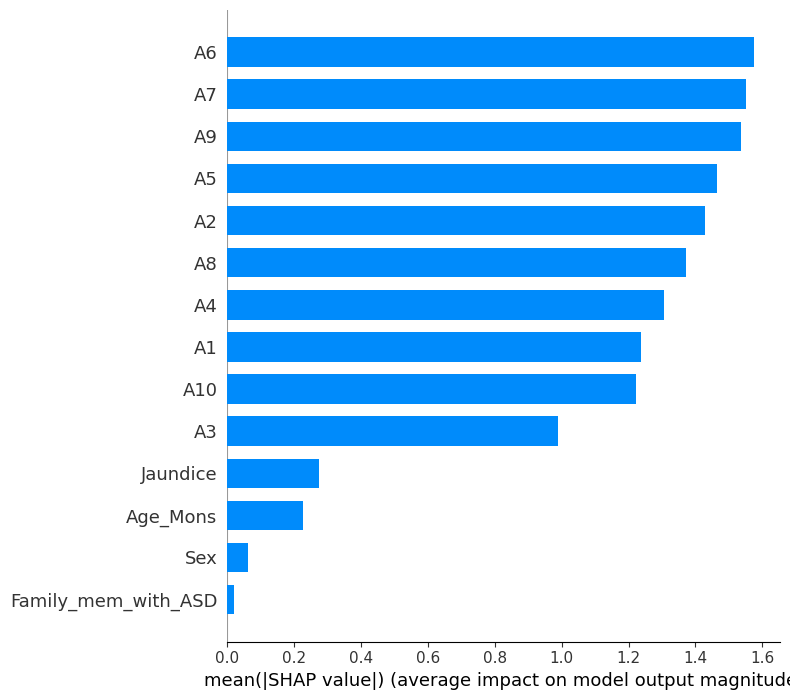

Saved as shap_summary.png


In [10]:
plt.figure()
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig('shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved as shap_summary.png")

In [11]:
#  first test row
sample = X_test.iloc[[0]]
sample_shap = explainer.shap_values(sample)

print("Actual label:", y_test.iloc[0])
print("Predicted label:", model.predict(sample)[0])
print("Predicted probability:", round(model.predict_proba(sample)[0][1], 3))

print("\nTop features for this prediction:")
feature_impact = list(zip(X_test.columns, sample_shap[0]))
feature_impact_sorted = sorted(feature_impact, key=lambda x: abs(x[1]), reverse=True)
for feat, val in feature_impact_sorted[:5]:
    direction = "increases" if val > 0 else "decreases"
    print(f"  {feat}: {direction} ASD likelihood (impact: {round(val, 3)})")

Actual label: 0
Predicted label: 0
Predicted probability: 0.018

Top features for this prediction:
  A2: increases ASD likelihood (impact: 2.7709999084472656)
  A6: increases ASD likelihood (impact: 1.8329999446868896)
  A7: decreases ASD likelihood (impact: -1.781000018119812)
  A10: decreases ASD likelihood (impact: -1.5180000066757202)
  A1: decreases ASD likelihood (impact: -1.3769999742507935)


In [12]:
feature_explanations = {
    'A1': 'Does not look at you when you call their name',
    'A2': 'Difficulty making eye contact',
    'A3': 'Does not point to show interest in things',
    'A4': 'Does not respond to smiling',
    'A5': 'Does not imitate actions',
    'A6': 'Does not notice when others are hurt',
    'A7': 'Unusual response to sounds',
    'A8': 'Repetitive behaviors like spinning or flapping',
    'A9': 'Limited facial expressions',
    'A10': 'Difficulty with back and forth interaction',
    'Age_Mons': 'Age in months',
    'Sex': 'Sex of child',
    'Jaundice': 'History of jaundice at birth',
    'Family_mem_with_ASD': 'Family history of ASD'
}

print("Top 3 reasons for this child's result:")
for feat, val in feature_impact_sorted[:3]:
    direction = "present" if val > 0 else "not a concern"
    explanation = feature_explanations.get(feat, feat)
    print(f"  - {explanation} ({direction})")

Top 3 reasons for this child's result:
  - Difficulty making eye contact (present)
  - Does not notice when others are hurt (present)
  - Unusual response to sounds (not a concern)


In [13]:
joblib.dump(explainer, 'spectra_explainer.pkl')
print("Explainer saved!")

# verify
loaded_explainer = joblib.load('spectra_explainer.pkl')
print("Explainer loaded back successfully!")

Explainer saved!

Explainer loaded back successfully!
